In [7]:
import sys
sys.path.append("../..")
from utils.processing import json_file_access
from beir.datasets.data_loader import GenericDataLoader
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import plotly.express as px

def differ_query_types(query):
    if query.startswith("INEX_LD"):
        return "INEX-LD"
    elif query.startswith("QALD2"):
        return "QALD-2"
    elif query.startswith("SemSearch_ES"):
        return "SemSearch ES"
    else:
        return "ListSearch"

In [3]:
rq1_ir_res = json_file_access("../../05_results/rq1/results_rq1.json", "r")
corpus, queries, qrels = GenericDataLoader(data_folder="../../03_data/raw_data/beir_dbpedia/dbpedia-entity").load(split="test")

  0%|          | 0/4635922 [00:00<?, ?it/s]

In [4]:
from collections import defaultdict
results_rq1 = defaultdict(dict)

for key, value in rq1_ir_res.items():
    for query, result in value.items():
        results_rq1[key][query] = []
        for i, doc_id in enumerate(result.keys()):
            results_rq1[key][query].append(doc_id)

In [6]:
res_all_kg1 = {}
res_all_kg2 = {}

configuration = {
    "cs_methods": ["LFMLocal", "GCE", "LocalTightnessExpansion"],
    "cs_core_node_number": [10,20,30]
}

# Iteratively add CS Top100
for cs in configuration["cs_methods"]:
    for cs_core_no in configuration["cs_core_node_number"]:
        res_all_kg2[cs + "_" + str(cs_core_no)] = json_file_access(f"../../05_results/rq2/cs/kg2_results_rq2_cs_{cs}_{cs_core_no}_all_community.json", "r")
        res_all_kg1[cs + "_" + str(cs_core_no)] = json_file_access(f"../../05_results//rq2/cs/kg1_results_rq2_cs_{cs}_{cs_core_no}_all_community.json", "r")

# # Manually add RQ1 results
res_all_kg1["RQ1" + "_" + str(0)] = results_rq1

In [10]:
# Calc Community Recall in KG1 and KG2
resi = defaultdict(dict)
q_dep_all = defaultdict(dict)

for ir_type in ["hybrid"]:
    for cn  in [10, 20, 30]:
        cs_type = "GCE_" + str(cn)
        resi["kg1_rel"][cn] = {}
        resi["kg2_rel"][cn]={}
        for query in res_all_kg1[cs_type][ir_type].keys():
            # if differ_query_types(query) != "ListSearch":
            #     continue
            resi["kg1_rel"][cn][query] = 0.0
            resi["kg2_rel"][cn][query] = 0.0
            relevance_query = sum(1 for value in qrels[query].values() if value >= 1)
            for doc, relevance in qrels[query].items(): # Loop through all qrel docs
                if doc in res_all_kg1["RQ1_0"][ir_type][query][:cn]: # doc is in the results
                    continue
                if relevance >= 1:
                    if doc in res_all_kg1[cs_type][ir_type][query]: # doc is in the results
                        resi["kg1_rel"][cn][query] +=1/relevance_query
                    if doc in res_all_kg2[cs_type][ir_type][query]:
                        resi["kg2_rel"][cn][query] +=1/relevance_query



In [8]:
query_all = {"INEX-LD":0, "QALD-2": 0, "SemSearch ES":0,"ListSearch":0}
for query in queries.keys():
    q_type = differ_query_types(query)
    query_all[q_type] += 1

In [11]:
query_dependence = defaultdict(dict)
for kg, cns in resi.items():
    for cn, values in cns.items():
        query_dependence[kg][cn] = {}
        for query, value in values.items():
            q_type = differ_query_types(query)
            if value == 0.0:
                if q_type not in query_dependence[kg][cn].keys():
                    query_dependence[kg][cn][q_type] = 1
                else:
                    query_dependence[kg][cn][q_type] += 1

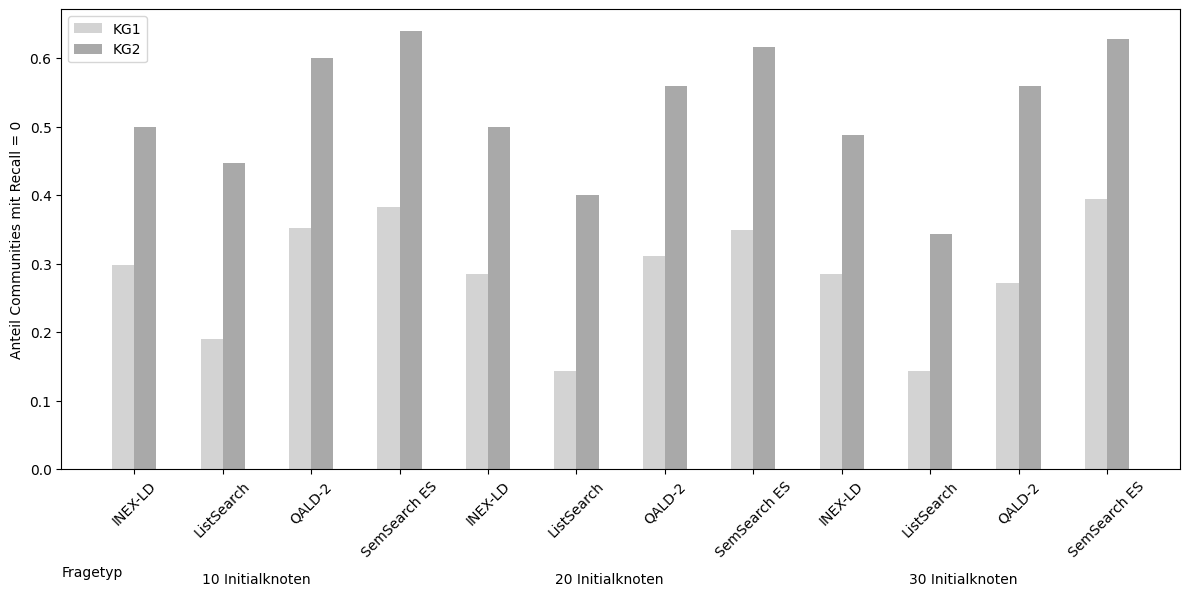

In [13]:
# Abbildung 37
# Flatten the dictionary for plotting
flat_data = {'kg1_rel': [], 'kg2_rel': []}
categories = list(query_dependence['kg1_rel'][10].keys())
x_labels = []

for k in query_dependence['kg1_rel'].keys():
    for cat in categories:
        flat_data['kg1_rel'].append(query_dependence['kg1_rel'][k][cat]/query_all[cat])
        flat_data['kg2_rel'].append(query_dependence['kg2_rel'][k][cat]/query_all[cat])
        x_labels.append(f"{cat}")

# Plotting
plt.figure(figsize=(12, 6))
bar_width = 0.25
index = np.arange(len(x_labels))

plt.bar(index, flat_data['kg1_rel'], bar_width, label='KG1', color = "lightgrey")
plt.bar(index + bar_width, flat_data['kg2_rel'], bar_width, label='KG2', color ="darkgrey")

plt.xlabel('Fragetyp', loc="left")
plt.ylabel('Anteil Communities mit Recall = 0')
plt.xticks(index + bar_width / 2, x_labels, rotation=45)
plt.legend()
plt.tight_layout()
group_labels = ["10 Initialknoten", "20 Initialknoten", "30 Initialknoten"]
for i, label in enumerate(group_labels):
    plt.text(i * 4 + 1.5, -0.15, label, ha='center', va='top', fontsize=10, color='black', rotation=0)
plt.savefig("Abbildung_37.svg")
plt.show()

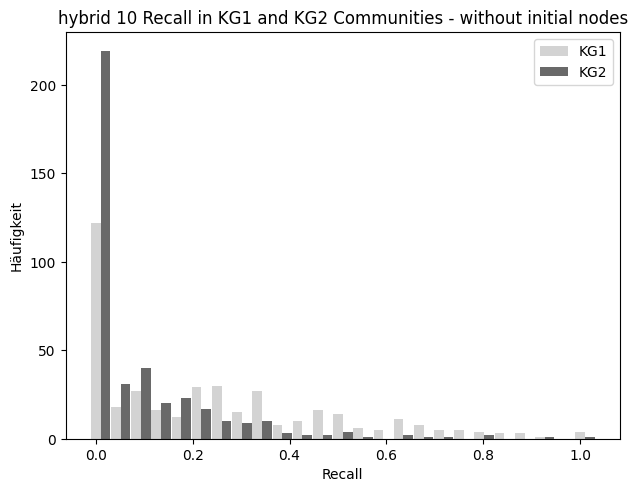

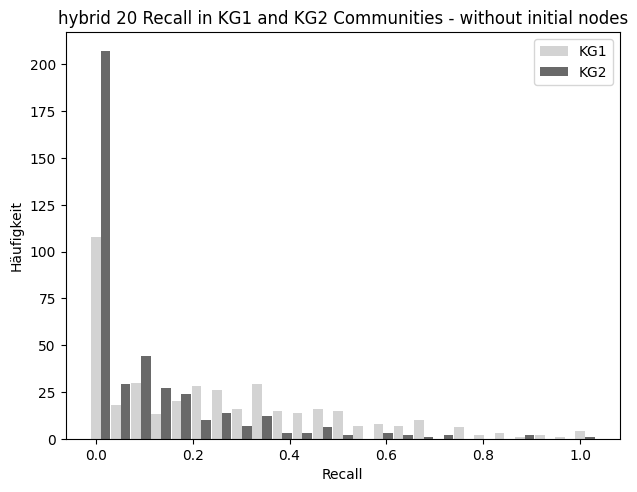

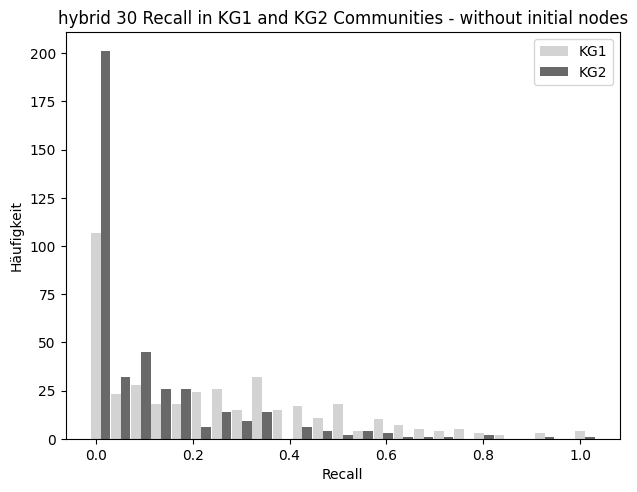

In [16]:
# Calc Community Recall in KG1 and KG2
resi = defaultdict(dict)

for ir_type in ["hybrid"]:
    for cn  in [10,20,30]:
        cs_type = "GCE_" + str(cn)
        for query in res_all_kg1[cs_type][ir_type].keys():
            # if differ_query_types(query) != "ListSearch":
            #     continue
            resi["kg1_rel"][query] = 0.0
            resi["kg2_rel"][query] = 0.0
            relevance_query = sum(1 for value in qrels[query].values() if value >= 1)
            for doc, relevance in qrels[query].items(): # Loop through all qrel docs
                if doc in res_all_kg1["RQ1_0"][ir_type][query][:cn]: # doc is in the results
                    continue
                if relevance >= 1:
                    if doc in res_all_kg1[cs_type][ir_type][query]: # doc is in the results
                        resi["kg1_rel"][query] +=1/relevance_query
                    if doc in res_all_kg2[cs_type][ir_type][query]:
                        resi["kg2_rel"][query] +=1/relevance_query

        hist_kg1= np.histogram(list(resi["kg1_rel"].values()),bins = [-0.001]+list(np.linspace(0.00000000001,1.0,25)))[0]
        hist_kg2= np.histogram(list(resi["kg2_rel"].values()),bins = [-0.001]+list(np.linspace(0.00000000001,1.0,25)))[0]

        plt.bar(np.linspace(0,1.0,len(hist_kg1)), hist_kg1, width=0.02, label='KG1', color ="lightgrey")
        plt.bar(np.linspace(0,1.0,len(hist_kg1))+0.02, hist_kg2, width=0.02, label='KG2', color = "dimgrey")

        plt.legend()
        plt.xlabel("Recall")
        plt.ylabel("Häufigkeit")
        plt.tight_layout()
        plt.title(f"{ir_type} {cn} Recall in KG1 and KG2 Communities - without initial nodes")
        plt.savefig(f"Recall-without-initial-nodes-{ir_type}-{cs_type}.svg")
        plt.show()